***

## Deep Learning & Generative AI - Exam Practice

## PRACTICAL 3 : CNN - MNIST DATA

***

#### Objective: Understand CNN Workflow

MNIST image → Convolution → ReLU → Max Pooling → Convolution → ReLU → Max Pooling → Flatten → Dense → Softmax Output

#### Theory Notes:

* **CNN (Convolutional Neural Network)** is a deep learning model mainly used for image processing and classification.
* **Convolution layer** extracts important features such as edges and patterns using filters.
* **ReLU** introduces non-linearity and is commonly used after convolution.
* **Max Pooling** reduces the spatial size of feature maps and keeps important features.
* **Flatten** converts feature maps into a one-dimensional vector.
* **Dense layer** performs classification using the extracted features.
* **Softmax** converts the final outputs into probabilities for the 10 digit classes.
* MNIST contains grayscale handwritten digits from **0 to 9**, where each image is **28 × 28 pixels**.

***

### 1] import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

### 2] load the MNIST dataset

MNIST contains grayscale images of handwritten digits from 0 to 9.

In [3]:
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print('Training images:', x_train_full.shape)
print('Test images:', x_test.shape)
print('Pixel range:', x_train_full.min(), 'to', x_train_full.max())

Training images: (60000, 28, 28)
Test images: (10000, 28, 28)
Pixel range: 0 to 255


### 3] use a smaller subset

A smaller subset is used to reduce practical training time while keeping the complete CNN workflow.

In [4]:
# Shuffle the training data
idx = np.random.permutation(len(x_train_full))
x_train_full = x_train_full[idx]
y_train_full = y_train_full[idx]

# Create training, validation and test subsets
x_train = x_train_full[:10000]
y_train = y_train_full[:10000]

x_val = x_train_full[10000:12000]
y_val = y_train_full[10000:12000]

x_test = x_test[:3000]
y_test = y_test[:3000]

print('Training:', x_train.shape)
print('Validation:', x_val.shape)
print('Testing:', x_test.shape)

Training: (10000, 28, 28)
Validation: (2000, 28, 28)
Testing: (3000, 28, 28)


### 4] visualize sample images

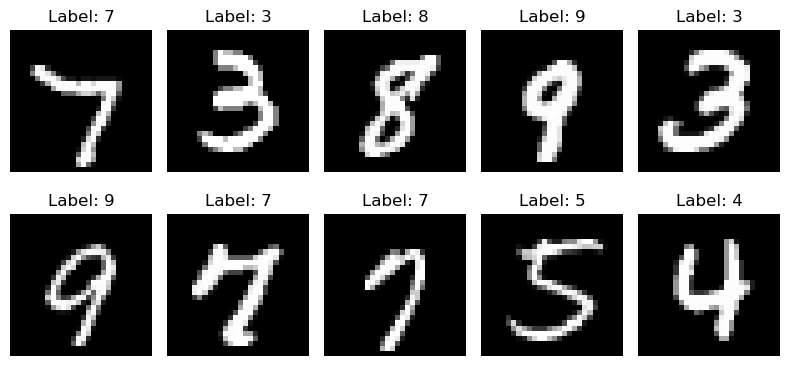

In [5]:
plt.figure(figsize=(8, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f'Label: {y_train[i]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

### 5] normalize and reshape the images

* Pixel values are scaled from **0–255 to 0–1**.
* A channel dimension is added because CNN expects image input in the form `(height, width, channels)`.

In [6]:
# Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_val = x_val.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Add channel dimension
x_train = np.expand_dims(x_train, -1)
x_val = np.expand_dims(x_val, -1)
x_test = np.expand_dims(x_test, -1)

print('Training shape:', x_train.shape)
print('Normalized range:', x_train.min(), 'to', x_train.max())

Training shape: (10000, 28, 28, 1)
Normalized range: 0.0 to 1.0


### 6] construct the CNN

##### Architecture:

1. Conv2D: 16 filters, 3 × 3
2. MaxPooling: 2 × 2
3. Conv2D: 32 filters, 3 × 3
4. MaxPooling: 2 × 2
5. Flatten
6. Dense: 32 neurons
7. Output: 10 neurons with Softmax

In [7]:
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(16, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1568)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │          50,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 55,338 (216.16 KB)

 Trainable params: 55,338 (216.16 KB)

 Non-trainable params: 0 (0.00 B)

### 7] layer sizes and parameter counts

For a convolution layer: `Parameters = (kernel height × kernel width × input channels + 1) × filters`

For a dense layer: `Parameters = (input units + 1) × output units`

In [8]:
for layer in model.layers:
    print(layer.name, '->', layer.count_params(), 'parameters')

print('Total parameters:', model.count_params())

conv2d -> 160 parameters
max_pooling2d -> 0 parameters
conv2d_1 -> 4640 parameters
max_pooling2d_1 -> 0 parameters
flatten -> 0 parameters
dense -> 50208 parameters
dense_1 -> 330 parameters
Total parameters: 55338


### 8] compile the CNN

* **Adam** is used as the optimizer.
* **Sparse categorical cross-entropy** is used because the labels are integers from 0 to 9.
* **Accuracy** measures correct classifications.

In [17]:
model.compile( optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

print('Model compiled successfully.')

Model compiled successfully.


### 9] train the CNN

In [10]:
# Train for a small number of epochs for practical use
history = model.fit( x_train, y_train,
                    validation_data=(x_val, y_val), epochs=5, 
                    batch_size=64, verbose=1 )

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7925 - loss: 0.7323 - val_accuracy: 0.9160 - val_loss: 0.2735
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9383 - loss: 0.2093 - val_accuracy: 0.9475 - val_loss: 0.1726
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9613 - loss: 0.1305 - val_accuracy: 0.9645 - val_loss: 0.1296
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9710 - loss: 0.0943 - val_accuracy: 0.9660 - val_loss: 0.1150
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9774 - loss: 0.0738 - val_accuracy: 0.9675 - val_loss: 0.1038


### 10] plot training and validation loss

A decreasing loss generally indicates that the model is improving its predictions.

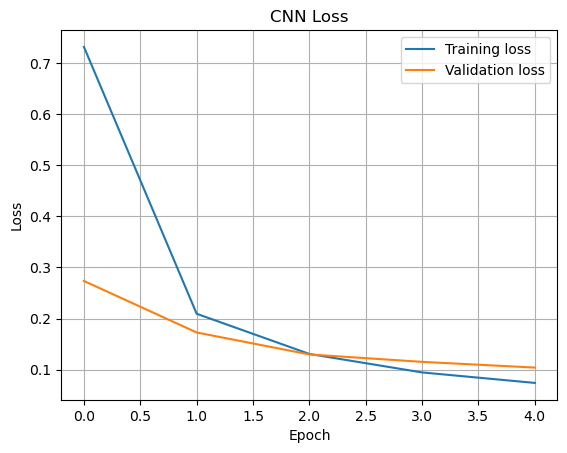

In [11]:
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Loss')
plt.legend()
plt.grid()
plt.show()

### 11] plot training and validation accuracy

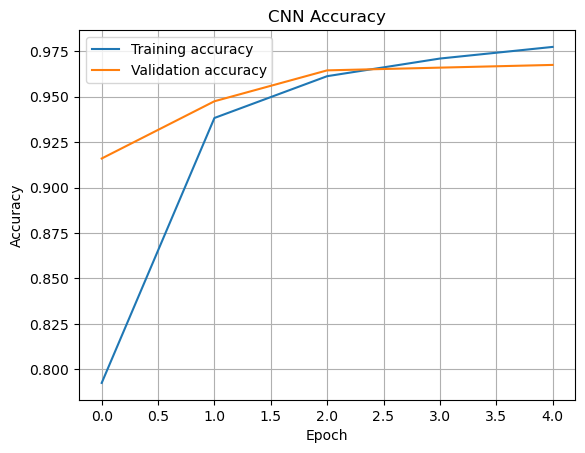

In [12]:
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy')
plt.legend()
plt.grid()
plt.show()

### 12] evaluate the CNN on test images

In [13]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print('Test Loss:', test_loss)
print('Test Accuracy:', test_accuracy)

Test Loss: 0.11428876966238022
Test Accuracy: 0.9643333554267883


### 13] generate predictions

In [14]:
probabilities = model.predict(x_test, verbose=0)
predicted_labels = np.argmax(probabilities, axis=1)
confidence = np.max(probabilities, axis=1)

prediction_table = pd.DataFrame({
    'Actual': y_test[:15],
    'Predicted': predicted_labels[:15],
    'Confidence': confidence[:15]
})

display(prediction_table)

,Actual,Predicted,Confidence
0,7,7,0.999969
1,2,2,0.999890
2,1,1,0.998555
3,0,0,0.999562
4,4,4,0.998054
5,1,1,0.996942
6,4,4,0.979437
7,9,9,0.667471
8,5,5,0.939695
9,9,9,0.992480


### 14] confusion matrix

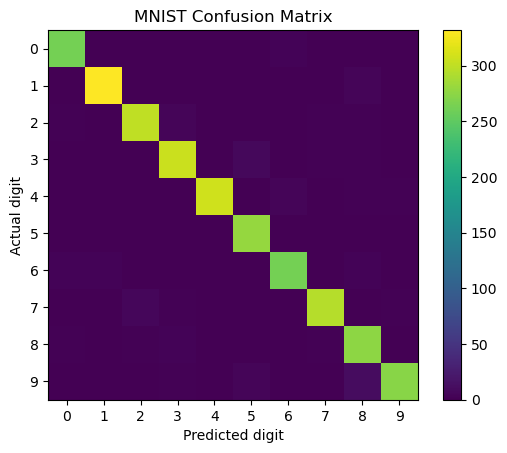

In [15]:
confusion = tf.math.confusion_matrix(y_test, predicted_labels, num_classes=10).numpy()

plt.imshow(confusion)
plt.title('MNIST Confusion Matrix')
plt.xlabel('Predicted digit')
plt.ylabel('Actual digit')
plt.xticks(range(10))
plt.yticks(range(10))
plt.colorbar()
plt.show()

### 15] visualize sample predictions

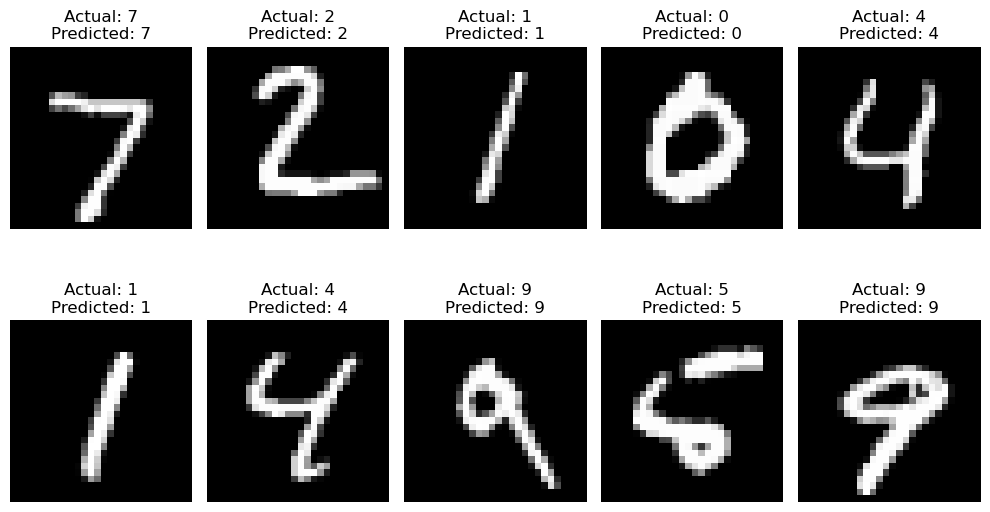

In [16]:
plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title(f'Actual: {y_test[i]}\nPredicted: {predicted_labels[i]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

***

### Quick Revision:

* **CNN:** Neural network mainly used for image processing and classification.
* **Convolution:** Extracts spatial features using filters.
* **ReLU:** Adds non-linearity after convolution.
* **Max Pooling:** Reduces feature-map size while retaining important information.
* **Flatten:** Converts feature maps into a 1D vector.
* **Softmax:** Gives probabilities for the 10 digit classes.
* **Normalization:** Converts pixel values from 0–255 to 0–1.
* **Input shape:** `28 × 28 × 1` for MNIST grayscale images.
* **Loss:** Sparse categorical cross-entropy.
* **Optimizer:** Adam.
* **Evaluation:** Test accuracy measures final classification performance.

***